# Fig: Infotaxis vs MAP, pm sweep: pmax_th=0.95

Reference: 
- `fig_S4_infotaxis_MAP_cmp_pfa0.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_success
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  995    right:  506
Mean:    left: 10.063  right: 13.164
Median:  left: 10.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  986    right:  499
Mean:    left: 10.273  right: 13.485
Median:  left: 10.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  995    right:  505
Mean:    left: 10.894  right: 14.182
Median:  left: 10.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  989    right:  490
Mean:    left: 11.413  right: 15.304
Median:  left: 11.000  right: 14.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


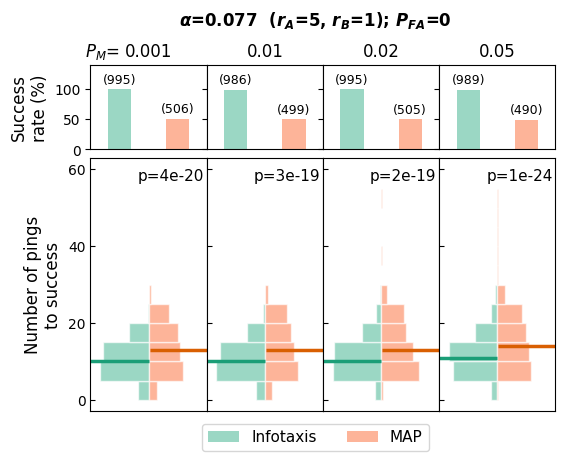

Samples: left:  997    right:  325
Mean:    left: 7.030  right: 8.575
Median:  left: 7.000  right: 8.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  987    right:  304
Mean:    left: 7.275  right: 9.211
Median:  left: 7.000  right: 9.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  977    right:  283
Mean:    left: 7.575  right: 9.703
Median:  left: 7.000  right: 9.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  981    right:  285
Mean:    left: 8.358  right: 9.828
Median:  left: 8.000  right: 10.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


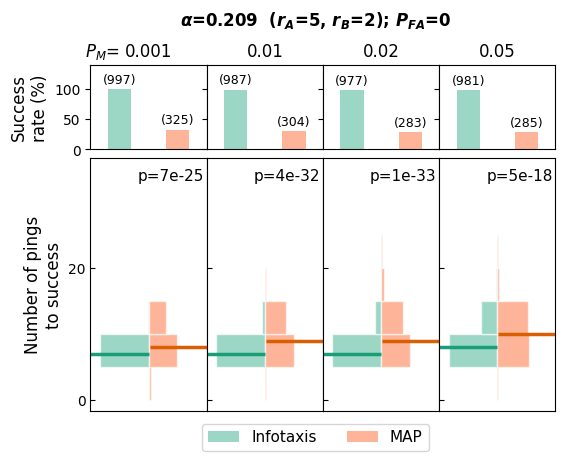

Samples: left:  996    right:  523
Mean:    left: 28.879  right: 34.314
Median:  left: 27.000  right: 32.000

MWU test
 - different: 0.00002
 - less:      0.00001
 - greater:   0.99999
--------------------------------------------
Samples: left:  985    right:  496
Mean:    left: 28.796  right: 34.710
Median:  left: 28.000  right: 30.000

MWU test
 - different: 0.00014
 - less:      0.00007
 - greater:   0.99993
--------------------------------------------
Samples: left:  991    right:  512
Mean:    left: 29.844  right: 38.963
Median:  left: 28.000  right: 36.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  987    right:  490
Mean:    left: 31.222  right: 40.290
Median:  left: 29.000  right: 36.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


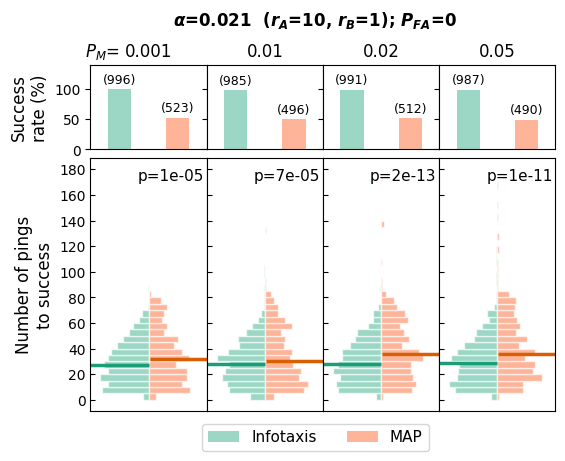

Samples: left:  998    right:  304
Mean:    left: 13.958  right: 18.207
Median:  left: 13.000  right: 17.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  985    right:  289
Mean:    left: 14.215  right: 18.657
Median:  left: 13.000  right: 18.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  974    right:  302
Mean:    left: 14.835  right: 19.626
Median:  left: 14.000  right: 18.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  993    right:  281
Mean:    left: 15.987  right: 20.975
Median:  left: 15.000  right: 19.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


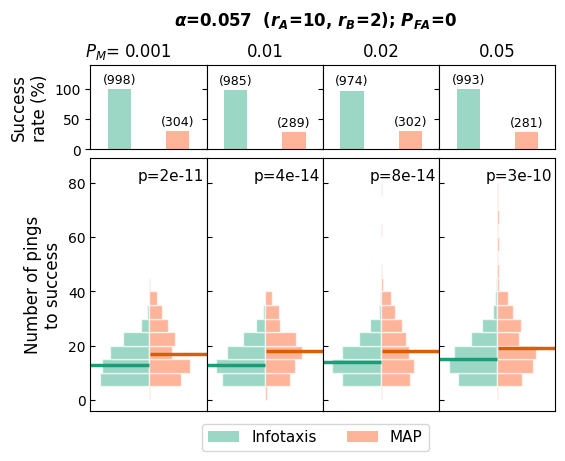

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_all = [0.001, 0.01, 0.02, 0.05]
pfa = 0

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260608_pm_sweep_infotaxis_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260608_pm_sweep_MAP_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm in pm_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="sweep",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm, pfa=pfa
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="sweep",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm, pfa=pfa
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)


        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pm_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Infotaxis", y_str="MAP",
            comparison_type="pm_sweep",
            stats_type="less",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=1,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_pm_sweep_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )